In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
# Load the dataset
df = pd.read_csv('data.csv')  # adjust filename to match your download
df.head()

print(df.columns.tolist())

['case', 'sex', 'age', 'sec', 'min', 'hour', 'date', 'month', 'year', 'country', 'i1', 'i2', 'i3', 'i4', 'i5', 'i6', 'i7', 'i8', 'i9', 'i10', 'i11', 'i12', 'i13', 'i14', 'i15', 'i16', 'i17', 'i18', 'i19', 'i20', 'i21', 'i22', 'i23', 'i24', 'i25', 'i26', 'i27', 'i28', 'i29', 'i30', 'i31', 'i32', 'i33', 'i34', 'i35', 'i36', 'i37', 'i38', 'i39', 'i40', 'i41', 'i42', 'i43', 'i44', 'i45', 'i46', 'i47', 'i48', 'i49', 'i50', 'i51', 'i52', 'i53', 'i54', 'i55', 'i56', 'i57', 'i58', 'i59', 'i60', 'i61', 'i62', 'i63', 'i64', 'i65', 'i66', 'i67', 'i68', 'i69', 'i70', 'i71', 'i72', 'i73', 'i74', 'i75', 'i76', 'i77', 'i78', 'i79', 'i80', 'i81', 'i82', 'i83', 'i84', 'i85', 'i86', 'i87', 'i88', 'i89', 'i90', 'i91', 'i92', 'i93', 'i94', 'i95', 'i96', 'i97', 'i98', 'i99', 'i100', 'i101', 'i102', 'i103', 'i104', 'i105', 'i106', 'i107', 'i108', 'i109', 'i110', 'i111', 'i112', 'i113', 'i114', 'i115', 'i116', 'i117', 'i118', 'i119', 'i120', 'i121', 'i122', 'i123', 'i124', 'i125', 'i126', 'i127', 'i128', 'i1

In [17]:
# Keep only Big Five scores

ocean_cols = [
    'openness',
    'conscientiousness',
    'extraversion',
    'agreeableness',
    'neuroticism'
]

df_ocean = df[ocean_cols].dropna()

df_ocean.head()

,openness,conscientiousness,extraversion,agreeableness,neuroticism
0,87.617239,96.159832,85.488835,98.671894,1.000000
1,21.501385,32.948049,66.767605,28.881780,39.208613
2,90.205420,20.059795,31.122227,78.817268,18.097775
3,1.000000,65.423909,5.109546,99.380609,80.696334
4,33.927915,82.419469,36.457593,72.713169,79.566290


In [18]:
df_ocean.describe()

,openness,conscientiousness,extraversion,agreeableness,neuroticism
count,145388.000000,145388.000000,145388.000000,145388.000000,145388.000000
mean,48.209435,49.855655,53.931998,52.860017,51.144125
std,28.314930,29.148908,28.610967,28.035658,28.987127
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,24.914390,25.259856,31.122227,31.338346,27.075921
50%,48.127295,50.574003,56.494957,55.196235,50.483538
75%,71.521857,74.127552,78.003665,76.160555,75.446499
max,99.674629,99.674671,99.674388,99.674793,99.674578


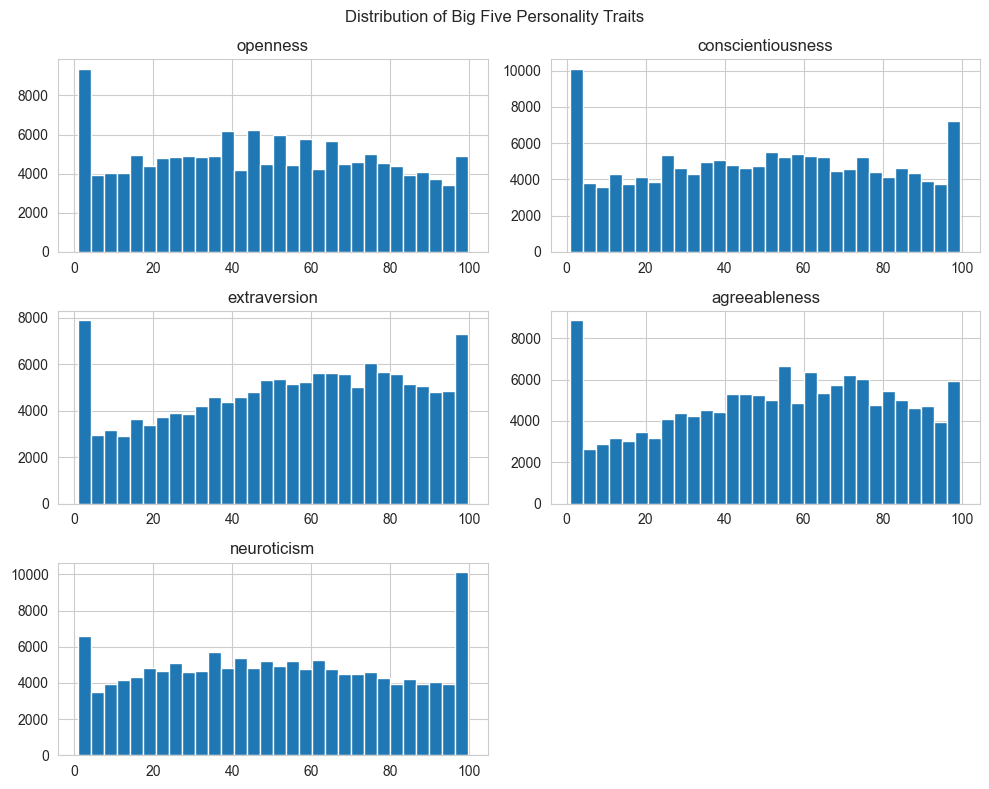

In [19]:
# Check distributions of personality traits

df_ocean.hist(figsize=(10, 8), bins=30)

plt.suptitle("Distribution of Big Five Personality Traits")

plt.tight_layout()
plt.show()

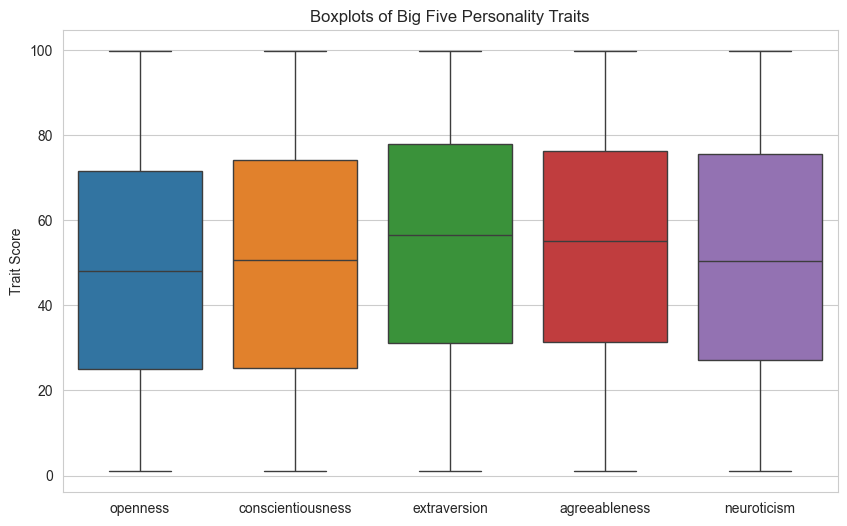

In [20]:
# Boxplots for outliers/spread

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_ocean)

plt.title("Boxplots of Big Five Personality Traits")
plt.ylabel("Trait Score")

plt.show()

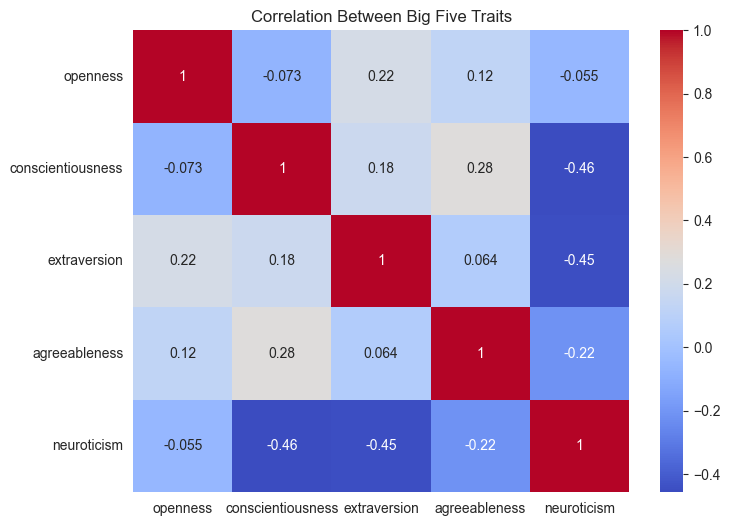

In [21]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_ocean.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Big Five Traits")

plt.show()

In [ ]:
# Normalize to 0-1 or standardize — important before K-means
scaler = StandardScaler()
X = scaler.fit_transform(df_ocean)
# Elbow method to pick number of clusters
inertias = []
k_range = range(2, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()